In [21]:
install.packages(c("lmtest", "sandwich", "dplyr"))


Installing packages into 'C:/Users/User/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependency 'zoo'




package 'zoo' successfully unpacked and MD5 sums checked
package 'lmtest' successfully unpacked and MD5 sums checked
package 'sandwich' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'dplyr'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problema al copiar C:\Users\User\AppData\Local\R\win-library\4.5\00LOCK\dplyr\libs\x64\dplyr.dll  a C:\Users\User\AppData\Local\R\win-library\4.5\dplyr\libs\x64\dplyr.dll: Permission denied"
Warning message:
"restored 'dplyr'"



The downloaded binary packages are in
	C:\Users\User\AppData\Local\Temp\RtmpctqyvQ\downloaded_packages


In [2]:
install.packages(c("igraph", "ggraph", "ggplot2"))

Installing packages into 'C:/Users/User/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'tweenr', 'polyclip', 'systemfonts', 'gridExtra', 'RcppArmadillo', 'ggforce', 'ggrepel', 'viridis', 'tidygraph', 'graphlayouts', 'S7'




package 'tweenr' successfully unpacked and MD5 sums checked
package 'polyclip' successfully unpacked and MD5 sums checked
package 'systemfonts' successfully unpacked and MD5 sums checked
package 'gridExtra' successfully unpacked and MD5 sums checked
package 'RcppArmadillo' successfully unpacked and MD5 sums checked
package 'ggforce' successfully unpacked and MD5 sums checked
package 'ggrepel' successfully unpacked and MD5 sums checked
package 'viridis' successfully unpacked and MD5 sums checked
package 'tidygraph' successfully unpacked and MD5 sums checked
package 'graphlayouts' successfully unpacked and MD5 sums checked
package 'S7' successfully unpacked and MD5 sums checked
package 'igraph' successfully unpacked and MD5 sums checked
package 'ggraph' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\User\AppData\Local\Temp\RtmpctqyvQ\downloaded_packages


In [14]:
URL <- "C:/Users/User/Desktop/Avances Asignación 03/R/Output/"


# Part 1a - Real life examples (2 points)


## 1.1) Explanation of Key Concepts (0.5 pts)

- **Confounder**  
  A confounder is a variable that simultaneously affects both the treatment (cause) and the outcome (effect). If not properly controlled, it generates a spurious or biased association, leading to incorrect inferences about causality.

- **Collider**  
  A collider is a variable that is influenced by two or more other variables. Conditioning on a collider (e.g., by including it as a control in regression analysis) can induce a false correlation between its determinants, thereby distorting the estimated relationships.

- **Mediator**  
  A mediator is a variable located on the causal pathway between the treatment and the outcome. It provides insight into the mechanism through which the treatment exerts its effect, helping to distinguish direct from indirect causal impacts.

## 1.2) Economics examples (1 pt)

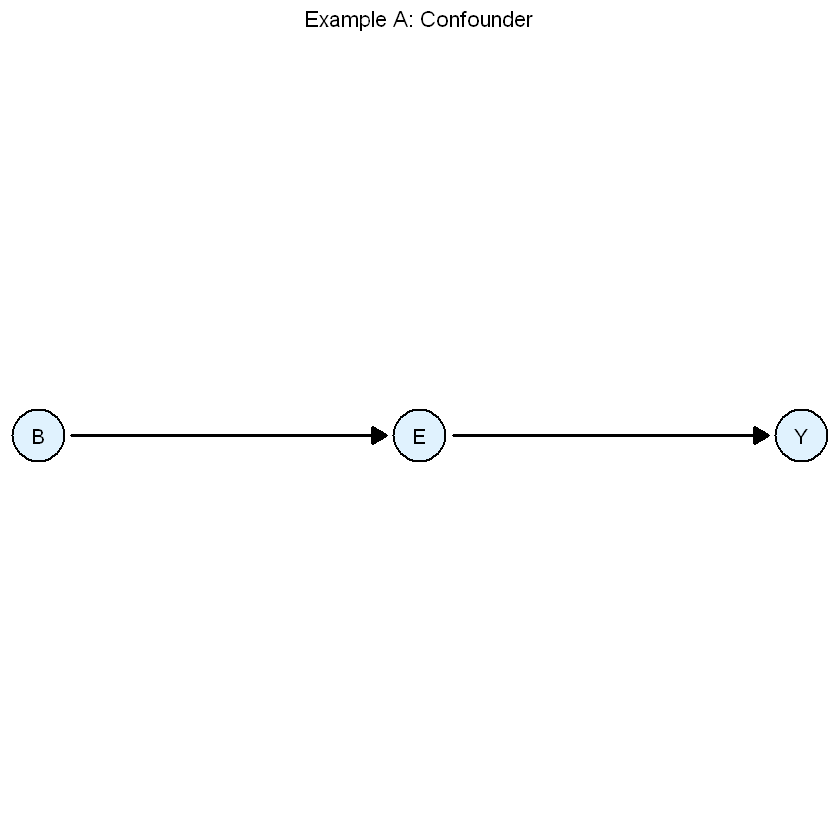

In [15]:
library(igraph)
library(ggraph)
library(ggplot2)

# Aristas SOLO en cadena B→E→Y
edges <- data.frame(from = c("B","E"), to = c("E","Y"))
g <- graph_from_data_frame(edges, directed = TRUE)

# Coordenadas fijas
coords <- data.frame(name=c("B","E","Y"),
                     x=c(0.0,1.2,2.4), y=c(0.6,0.6,0.6))
V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

p <- ggraph(g, layout="manual", x=V(g)$x, y=V(g)$y) +
  geom_edge_link(
    arrow = arrow(type="closed", length=unit(3.5,"mm")),
    start_cap = circle(7,"mm"), end_cap = circle(7,"mm"),
    edge_width = 1, lineend = "round"
  ) +
  geom_node_point(shape=21, size=14, fill="#e0f2fe", color="black", stroke=1.2) +
  geom_node_text(aes(label=name), size=4.5) +
  ggtitle("Example A: Confounder") +
  theme_void() +
  theme(plot.title = element_text(hjust=0.5))

print(p)

# Exporta usando URL ya definida en tu entorno
ggsave(filename = paste0(URL, "Confounder.png"),
       plot = p, width = 6, height = 2.4, dpi = 300)



### Example A: Confounder 
- **Treatment (E):** Years of education
- **Outcome (Y):** Future income
- **Confounder (B):** Family background (socioeconomic status)
- **Explanation:** Family background affects both the likelihood of obtaining more education and the level of income. If not controlled, the estimated effect of education on income will be biased.

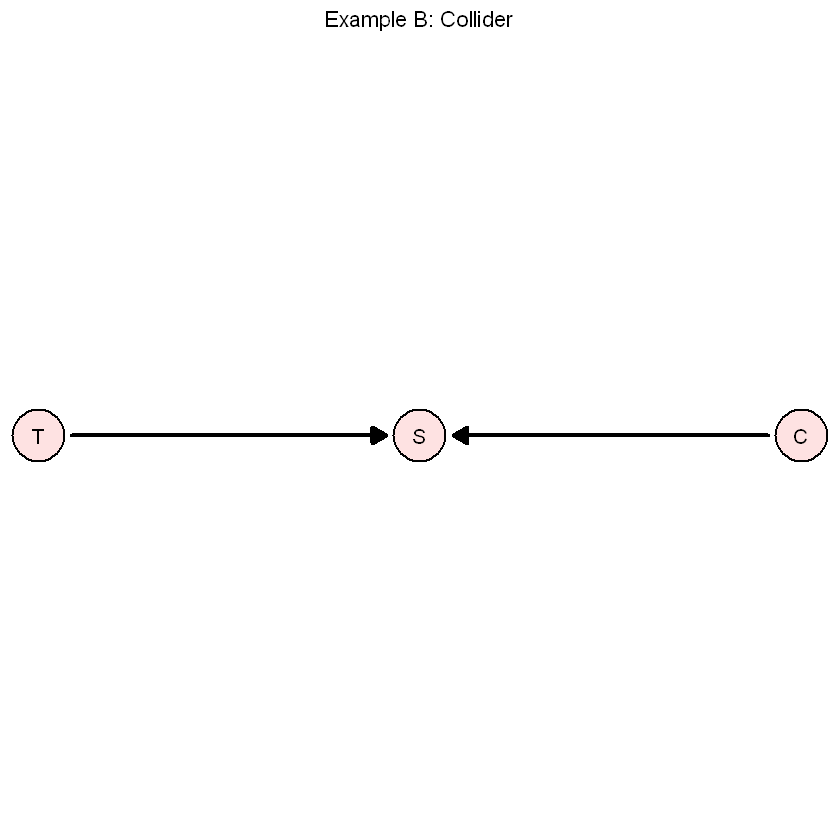

In [16]:
library(igraph)
library(ggraph)
library(ggplot2)

# Definir aristas
edges <- data.frame(
  from = c("T", "C"),
  to   = c("S", "S")
)

# Crear grafo dirigido
g <- graph_from_data_frame(edges, directed = TRUE)

# Coordenadas fijas
coords <- data.frame(
  name = c("T", "S", "C"),
  x = c(0.0, 1.2, 2.4),
  y = c(0.6, 0.6, 0.6)
)

V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

# Graficar
p <- ggraph(g, layout = "manual", x = V(g)$x, y = V(g)$y) +
  geom_edge_link(
    arrow = arrow(type = "closed", length = unit(3.5, "mm")),
    start_cap = circle(7, "mm"),
    end_cap   = circle(7, "mm"),
    edge_width = 1.2, lineend = "round"
  ) +
  geom_node_point(shape = 21, size = 14, fill = "#fee2e2", color = "black", stroke = 1.2) +
  geom_node_text(aes(label = name), size = 4.5) +
  ggtitle("Example B: Collider") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5))

print(p)

# Guardar imagen
ggsave(filename = paste0(URL, "Collider.png"),
       plot = p, width = 6, height = 2.4, dpi = 300)


### Example B: Collider  
- **Variable 1 (T):** Entrepreneurial talent  
- **Variable 2 (C):** Access to credit  
- **Collider (S):** Business survival  
- **Explanation:** Both talent and credit independently increase the chance of business survival. If we condition on survival (look only at businesses that survived), we may see a spurious negative correlation between talent and credit, even if none exists in the population.  

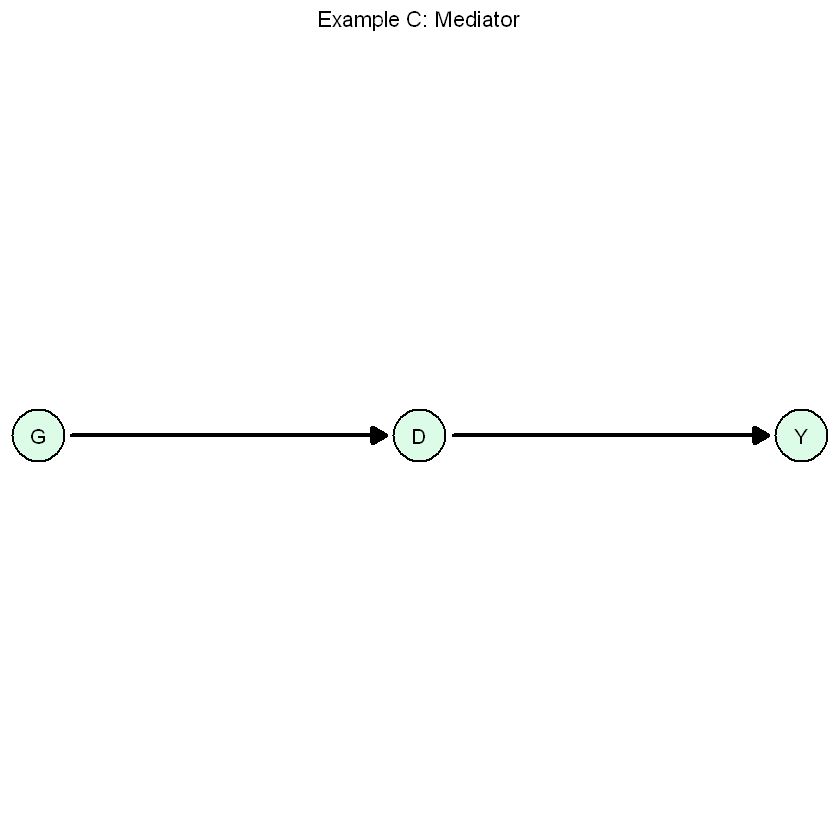

In [17]:
library(igraph)
library(ggraph)
library(ggplot2)

# Definir aristas
edges <- data.frame(
  from = c("G", "D"),
  to   = c("D", "Y")
)

# Crear grafo dirigido
g <- graph_from_data_frame(edges, directed = TRUE)

# Coordenadas fijas (alineado izquierda → derecha)
coords <- data.frame(
  name = c("G", "D", "Y"),
  x = c(0.0, 1.2, 2.4),
  y = c(0.6, 0.6, 0.6)
)

V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

# Graficar
p <- ggraph(g, layout = "manual", x = V(g)$x, y = V(g)$y) +
  geom_edge_link(
    arrow = arrow(type = "closed", length = unit(3.5, "mm")),
    start_cap = circle(7, "mm"),
    end_cap   = circle(7, "mm"),
    edge_width = 1.2, lineend = "round"
  ) +
  geom_node_point(shape = 21, size = 14, fill = "#dcfce7", color = "black", stroke = 1.2) +
  geom_node_text(aes(label = name), size = 4.5) +
  ggtitle("Example C: Mediator") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5))

print(p)

# Guardar imagen
ggsave(filename = paste0(URL, "Mediator.png"),
       plot = p, width = 6, height = 2.4, dpi = 300)



### Example C: Mediator  
- **Treatment (G):** Government spending  
- **Mediator (D):** Aggregate demand  
- **Outcome (Y):** Economic growth  
- **Explanation:** Government spending boosts aggregate demand, which then fosters economic growth. Aggregate demand transmits the effect of spending onto growth, so it is a mediator.  

# Part 1b - Simpson's paradox (2 points)


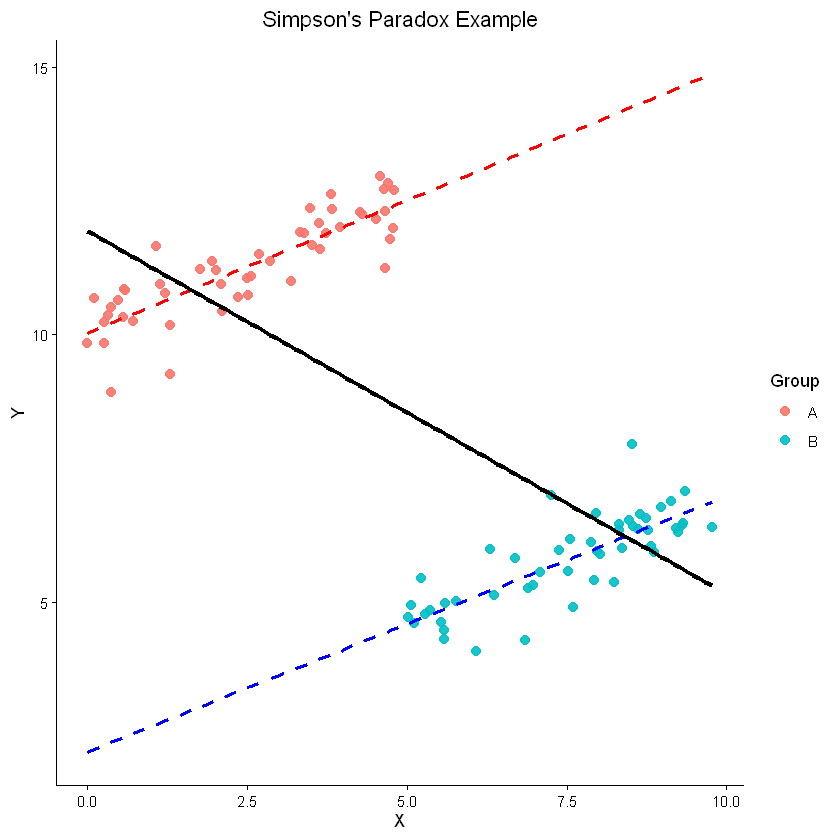

In [18]:
# Reproducibilidad
set.seed(222)

# Datos simulados (dos grupos con distintos interceptos)
n <- 50
X_A <- runif(n, 0, 5)
Y_A <- 0.5 * X_A + 10 + rnorm(n, 0, 0.5)

X_B <- runif(n, 5, 10)
Y_B <- 0.5 * X_B + 2 + rnorm(n, 0, 0.5)

df <- data.frame(
  X = c(X_A, X_B),
  Y = c(Y_A, Y_B),
  Group = factor(c(rep("A", n), rep("B", n)))
)

# Modelos OLS: por grupo y combinado
m_all <- lm(Y ~ X, data = df)
m_A   <- lm(Y ~ X, data = subset(df, Group == "A"))
m_B   <- lm(Y ~ X, data = subset(df, Group == "B"))

# Predicciones sobre rango común
x_vals <- data.frame(X = seq(min(df$X), max(df$X), length.out = 100))
pred_all <- data.frame(X = x_vals$X, Y = predict(m_all, newdata = x_vals), Model = "Fit All")
pred_A   <- data.frame(X = x_vals$X, Y = predict(m_A,   newdata = x_vals), Model = "Fit Group A")
pred_B   <- data.frame(X = x_vals$X, Y = predict(m_B,   newdata = x_vals), Model = "Fit Group B")
pred_df  <- rbind(pred_A, pred_B, pred_all)

# Gráfico
library(ggplot2)
p <- ggplot(df, aes(x = X, y = Y)) +
  geom_point(aes(color = Group), size = 2.5, alpha = 0.9) +
  geom_line(data = subset(pred_df, Model == "Fit Group A"),
            aes(y = Y), color = "red", linetype = "dashed", linewidth = 1) +
  geom_line(data = subset(pred_df, Model == "Fit Group B"),
            aes(y = Y), color = "blue", linetype = "dashed", linewidth = 1) +
  geom_line(data = subset(pred_df, Model == "Fit All"),
            aes(y = Y), color = "black", linewidth = 1.2) +
  labs(title = "Simpson's Paradox Example", x = "X", y = "Y") +
  theme_classic() +
  theme(plot.title = element_text(hjust = 0.5))

print(p)

# Exportar usando URL ya definida en tu entorno
ggsave(filename = paste0(URL, "simpsons_paradox.png"),
       plot = p, width = 8, height = 6, dpi = 300)


# Part 2 - Can we omit some controls? (7 points)


## 2.1)  Graphic DAG (1 point)

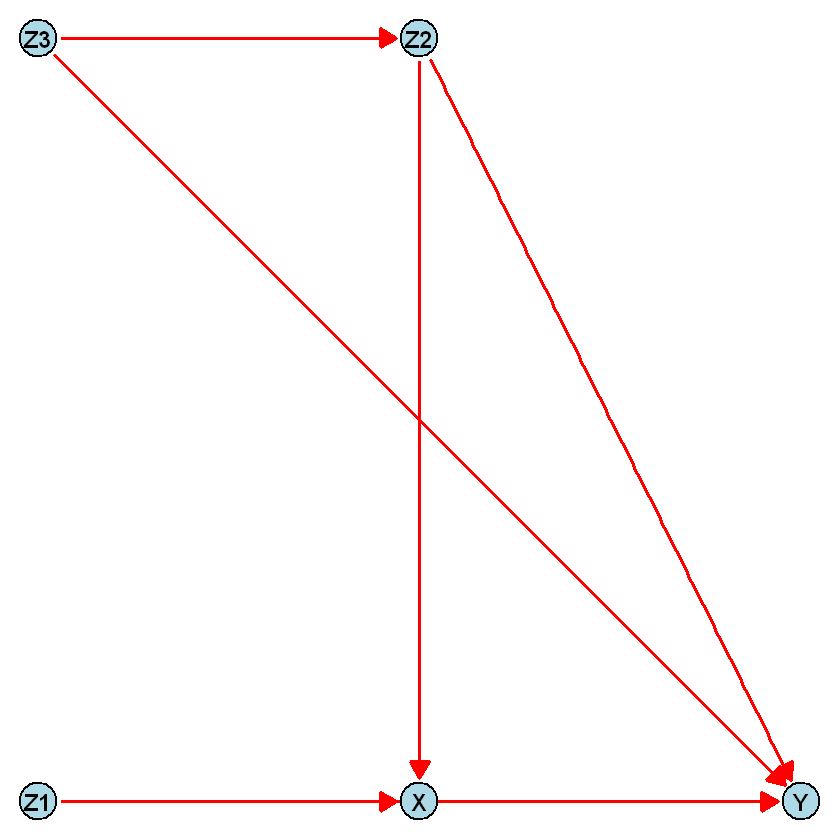

In [19]:
library(igraph)
library(ggraph)
library(ggplot2)

# Definir aristas
edges <- data.frame(
  from = c("Z1", "Z1", "Z2", "Z2", "Z3", "Z3", "X"),
  to   = c("X", "Y", "X", "Y", "Z2", "Y", "Y")
)

# Crear grafo dirigido
g <- graph_from_data_frame(edges, directed = TRUE)

# Coordenadas fijas
coords <- data.frame(
  name = c("Z3", "Z2", "Z1", "X", "Y"),
  x = c(0.0, 1.2, 0.0, 1.2, 2.4),
  y = c(1.8, 1.8, 0.9, 0.9, 0.9)
)

V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

# Graficar
p <- ggraph(g, layout = "manual", x = V(g)$x, y = V(g)$y) +
  geom_edge_link(
    arrow = arrow(type = "closed", length = unit(4, "mm")),
    start_cap = circle(5, "mm"),
    end_cap   = circle(5, "mm"),
    edge_colour = "red",    # color de aristas
    edge_width = 1
  ) +
  geom_node_point(shape = 21, size = 10, fill = "lightblue", color = "black", stroke = 1.1) +
  geom_node_text(aes(label = name), size = 5, fontface = "bold") +
  theme_void()

print(p)

# Exportar imagen (usa tu carpeta definida en URL)
ggsave(filename = paste0(URL, "DAG_Can_We_Omite_Some_Control.png"),
       plot = p, width = 7, height = 4, dpi = 300)



## 2.2) Simulation (1 point)

In [20]:
set.seed(123); n <- 5000
e <- function() rnorm(n)

Z3 <- e()
Z2 <- Z3 + e()
Z1 <- e()
X  <- Z1 + Z2 + e()
Y  <- X + Z1 + Z2 + Z3 + e()

df <- data.frame(Y = Y, X = X, Z1 = Z1, Z2 = Z2, Z3 = Z3)


## 2.3) Regressions (2 point)

In [24]:
# Paquetes
library(lmtest)
library(sandwich)
library(dplyr)

# Aux: OLS + SE robustos HC1
fit <- function(formula, data) {
  model <- lm(formula, data = data)
  coefs <- coeftest(model, vcov = vcovHC(model, type = "HC1"))
  list(model = model, coefs = coefs)
}

# Modelos
m1 <- fit(Y ~ X, df)
m2 <- fit(Y ~ X + Z1, df)
m3 <- fit(Y ~ X + Z2, df)
m4 <- fit(Y ~ X + Z1 + Z2, df)
m5 <- fit(Y ~ X + Z1 + Z2 + Z3, df)

models <- list(m1, m2, m3, m4, m5)
labels <- c("(1) Y~X",
            "(2) Y~X+Z1",
            "(3) Y~X+Z2",
            "(4) Y~X+Z1+Z2",
            "(5) Y~X+Z1+Z2+Z3")

# Fila de resumen segura
row_from_model <- function(m, name = "X") {
  rn <- rownames(m$coefs)
  if (!(name %in% rn)) {
    est <- se <- t <- p <- NA_real_
  } else {
    est <- m$coefs[name, 1]
    se  <- m$coefs[name, 2]
    t   <- m$coefs[name, 3]
    p   <- m$coefs[name, 4]
  }
  z <- 2.575
  ci_low  <- est - z * se
  ci_high <- est + z * se
  stars <- if (is.na(p)) "" else if (p < 0.01) "***" else if (p < 0.05) "**" else if (p < 0.1) "*" else ""
  r2 <- summary(m$model)$r.squared
  n  <- nobs(m$model)

  data.frame(
    `Coef X` = est,
    `SE(X)`  = se,
    `CI99%`  = ifelse(is.na(est), NA, sprintf("[%.3f, %.3f]", ci_low, ci_high)),
    `t(X)`   = t,
    `p(X)`   = p,
    Sig      = stars,
    R2       = r2,
    n        = n,
    check.names = FALSE
  )
}

summary_df <- bind_rows(lapply(models, row_from_model), .id = "Model") |>
  mutate(Model = labels)

# Formateo
fmt <- summary_df |>
  mutate(
    `Coef X` = ifelse(is.na(`Coef X`), NA, sprintf("%.3f", `Coef X`)),
    `SE(X)`  = ifelse(is.na(`SE(X)`),  NA, sprintf("%.3f", `SE(X)`)),
    `t(X)`   = ifelse(is.na(`t(X)`),   NA, sprintf("%.2f", `t(X)`)),
    `p(X)`   = ifelse(is.na(`p(X)`),   NA, sprintf("%.3g", `p(X)`)),
    R2       = sprintf("%.3f", R2),
    n        = format(n, big.mark = ",")
  )

print(fmt, row.names = FALSE)


            Model Coef X SE(X)          CI99%   t(X) p(X) Sig    R2     n
          (1) Y~X  2.010 0.012 [1.978, 2.042] 162.55    0 *** 0.841 5,000
       (2) Y~X+Z1  2.000 0.014 [1.964, 2.037] 141.15    0 *** 0.841 5,000
       (3) Y~X+Z2  1.512 0.015 [1.474, 1.550] 102.10    0 *** 0.891 5,000
    (4) Y~X+Z1+Z2  1.008 0.018 [0.963, 1.054]  56.66    0 *** 0.919 5,000
 (5) Y~X+Z1+Z2+Z3  1.015 0.015 [0.977, 1.053]  68.62    0 *** 0.947 5,000


## 2.4) 99% Confidence Intervals (2 point)

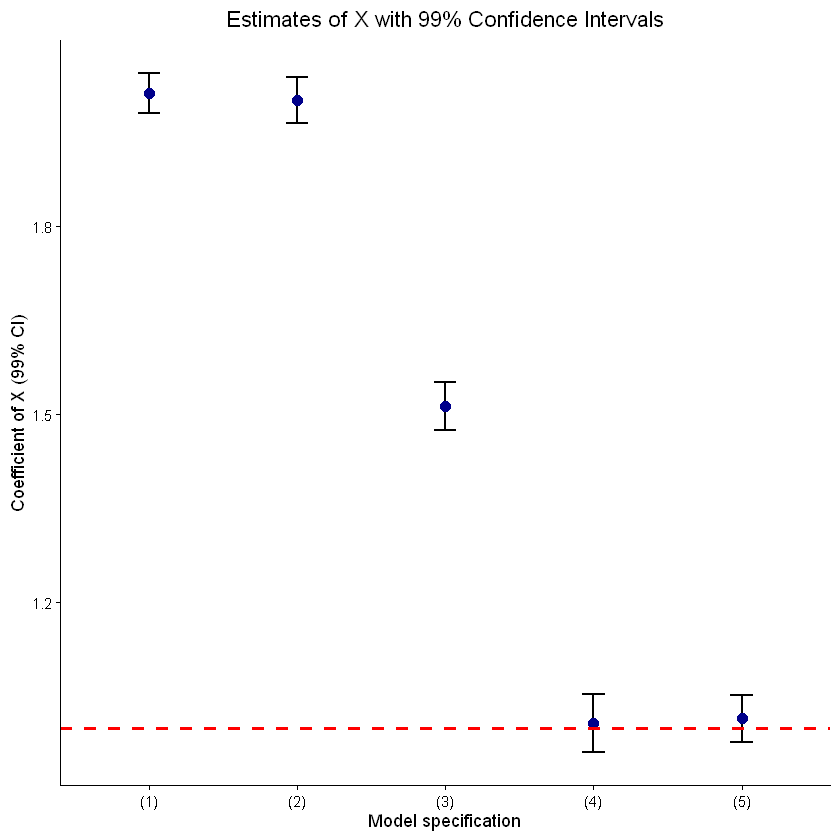

In [25]:
# 99% CI plot for coefficient of X across models m1..m5 (HC1 SEs)

library(ggplot2)
library(dplyr)

# Helper to extract est and 99% CI for "X" using robust SEs already in m$coefs
ci99 <- function(m, var = "X") {
  if (!(var %in% rownames(m$coefs))) {
    return(data.frame(est = NA_real_, se = NA_real_, lo = NA_real_, hi = NA_real_))
  }
  est <- m$coefs[var, 1]
  se  <- m$coefs[var, 2]
  z   <- 2.575
  data.frame(est = est, se = se, lo = est - z * se, hi = est + z * se)
}

labels <- c("(1)", "(2)", "(3)", "(4)", "(5)")
cis <- lapply(list(m1, m2, m3, m4, m5), ci99)
df_ci <- bind_rows(cis) |> mutate(Model = factor(labels, levels = labels)) |> relocate(Model)

p <- ggplot(df_ci, aes(x = Model, y = est)) +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 0.15, linewidth = 0.8, color = "black") +
  geom_point(size = 2.8, color = "darkblue") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", linewidth = 1) +
  labs(
    title = "Estimates of X with 99% Confidence Intervals",
    x = "Model specification",
    y = "Coefficient of X (99% CI)"
  ) +
  theme_classic() +
  theme(plot.title = element_text(hjust = 0.5))

print(p)

# Exporta usando URL ya definida en tu entorno
ggsave(filename = paste0(URL, "DAG_Confidence Intervals.png"),
       plot = p, width = 8, height = 5, dpi = 300)


## Questions

### 2.5). Which regressions correctly estimate the effect?  (1 point)
The regressions that provide an unbiased estimate of the causal effect of $X$ on $Y$ are **(4)** and **(5)**.  
In (4) $Y \sim X + Z_{1} + Z_{2}$ all backdoors are blocked by controlling for the confounders $Z_{1}, Z_{2}$.  
In (5) $Y \sim X + Z_{1} + Z_{2} + Z_{3}$ as well, but $Z_{3}$ is redundant since it is an ancestor of $Z_{2}$.


### 2.6). Summary table (models 4 and 5) (0.5 point)

| Model | $\hat{\alpha}_{X}$ | SE($\hat{\alpha}_{X}$) | 99% CI          | $R^{2}$ | $n$   |
|:-----:|:------------------:|:----------------------:|:---------------:|:-------:|:-----:|
|  (4)  | 1.008              | 0.018                  | [0.963, 1.054]  | 0.919   | 5000  |
|  (5)  | 1.015              | 0.015                  | [0.977, 1.053]  | 0.947   | 5000  |

**Comment.** $\hat{\alpha}_{X}$ is very close to $\alpha=1$; the 99% confidence intervals include 1; the standard errors are small.  
The higher $R^{2}$ in (5) results from adding $Z_{3}$, which is unnecessary for identification.


### 2.7). Can any $Z$ be ignored?  (0.5 point)
Yes. $Z_{3}$ can be omitted. With $\{Z_{1}, Z_{2}\}$ the backdoor criterion is already satisfied; including $Z_{3}$ does not reduce bias and may harm efficiency due to collinearity.

**Conclusion.** The minimally sufficient adjustment set is $\{Z_{1}, Z_{2}\}$.



# Part 3 - Damned if you do, damned if you don't (9 points)


## 3.1) Graphic DAG (1 point) 

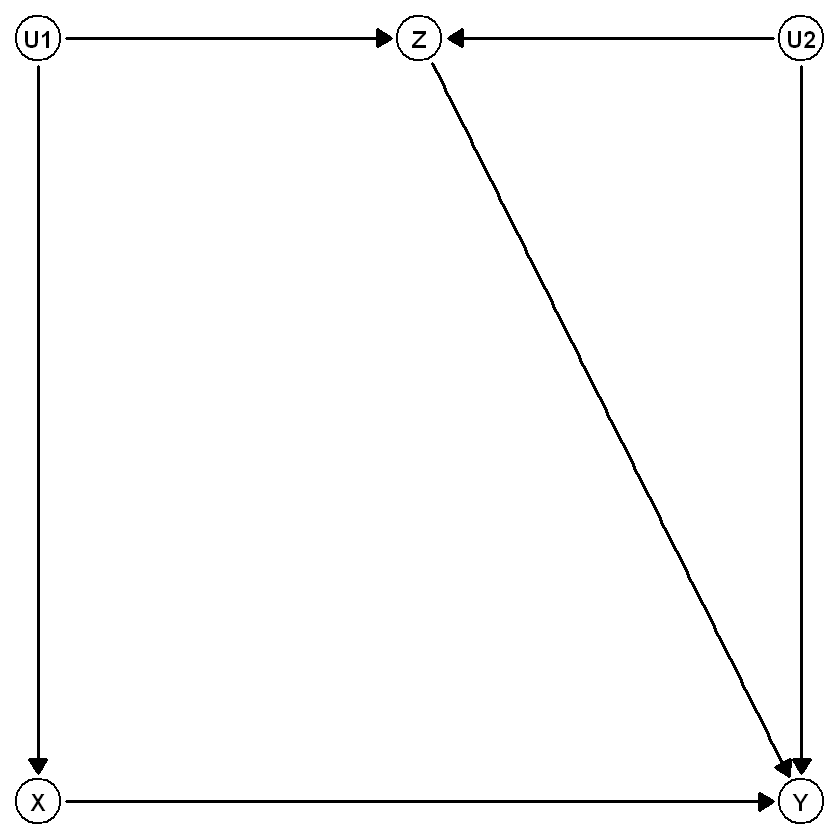

In [26]:
library(igraph)
library(ggraph)
library(ggplot2)

# Aristas del DAG
edges <- data.frame(
  from = c("U1","U2","U1","Z","U2","X"),
  to   = c("Z","Z","X","Y","Y","Y")
)

g <- graph_from_data_frame(edges, directed = TRUE)

# Posiciones fijas de los nodos
coords <- data.frame(
  name = c("U1","Z","U2","X","Y"),
  x = c(0.0, 1.2, 2.4, 0.0, 2.4),
  y = c(1.2, 1.2, 1.2, 0.0, 0.0)
)

# Asociar coordenadas al grafo
V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

# Graficar
p <- ggraph(g, layout = "manual", x = V(g)$x, y = V(g)$y) +
  geom_edge_link(
    arrow = arrow(type = "closed", length = unit(3.5,"mm")),
    end_cap = circle(6,"mm"), start_cap = circle(6,"mm"),
    edge_width = 1, lineend = "round", color = "black"
  ) +
  geom_node_point(shape = 21, size = 12, fill = "white", color = "black", stroke = 1.2) +
  geom_node_text(aes(label = name), size = 5, fontface = "bold") +
  theme_void()

print(p)

# Guardar a archivo (si ya definiste URL)
ggsave(filename = paste0(URL, "DAG_damned.png"),
       plot = p, width = 7, height = 4, dpi = 300)



## 3.2) Regressions (1 point) 

In [27]:
# Reproducibility
set.seed(123)
n <- 50000

# Exogenous shocks
U1 <- rnorm(n)
U2 <- rnorm(n)

# DAG definition
Z <- U1 + U2 + rnorm(n)     # collider
X <- U1 + rnorm(n)          # treatment
Y <- 1*X + 1*U2 + 1*Z + rnorm(n)  # outcome

df <- data.frame(Y = Y, X = X, Z = Z, U1 = U1, U2 = U2)

# OLS with HC1 robust SEs
library(lmtest)
library(sandwich)

fit_hc1 <- function(formula, data) {
  mod <- lm(formula, data = data)
  list(model = mod, coefs = coeftest(mod, vcov = vcovHC(mod, type = "HC1")))
}

# 1) Model without Z
m0 <- fit_hc1(Y ~ X, df)

# 2) Model controlling for Z
m1 <- fit_hc1(Y ~ X + Z, df)

# Short summary
report <- function(m, var = "X", level = 0.95) {
  est <- m$coefs[var, 1]
  se  <- m$coefs[var, 2]
  z   <- qnorm(1 - (1 - level)/2)  # 1.96 for 95%
  lo  <- est - z*se
  hi  <- est + z*se
  sprintf("%s: %.3f (SE=%.3f, %.0f%% CI [%.3f, %.3f])",
          var, est, se, level*100, lo, hi)
}

cat("== Y ~ X ==\n")
cat(report(m0, "X"), "\n\n")

cat("== Y ~ X + Z ==\n")
cat(report(m1, "X"), "\n")


== Y ~ X ==
X: 1.493 (SE=0.008, 95% CI [1.477, 1.508]) 

== Y ~ X + Z ==
X: 0.801 (SE=0.004, 95% CI [0.793, 0.810]) 


## 3.3) 99% Confidence Intervals (1 point)

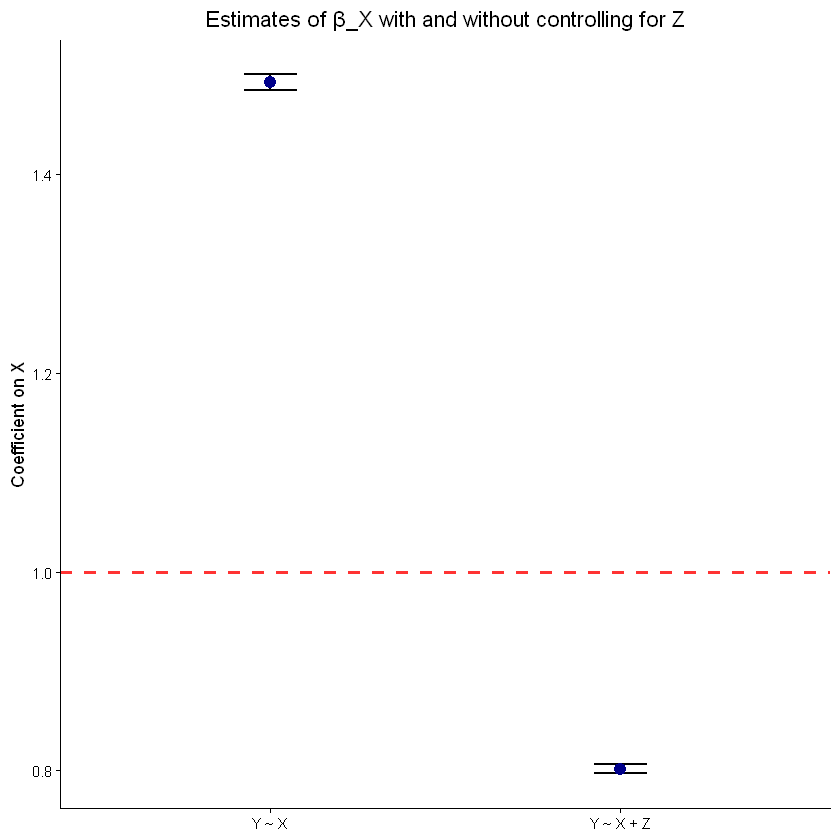

In [28]:
library(ggplot2)

# Extraer coeficientes y SE de X
ests <- c(m0$coefs["X", 1], m1$coefs["X", 1])
ses  <- c(m0$coefs["X", 2], m1$coefs["X", 2])
labels <- c("Y ~ X", "Y ~ X + Z")

df_plot <- data.frame(
  Model = factor(labels, levels = labels),
  est   = ests,
  se    = ses
)

# Graficar
p <- ggplot(df_plot, aes(x = Model, y = est)) +
  geom_errorbar(aes(ymin = est - se, ymax = est + se),
                width = 0.15, linewidth = 0.8) +
  geom_point(size = 3, color = "darkblue") +
  geom_hline(yintercept = 1.0, color = "red", linetype = "dashed",
             linewidth = 1, alpha = 0.8) +
  labs(
    title = "Estimates of β_X with and without controlling for Z",
    y = "Coefficient on X", x = NULL
  ) +
  theme_classic() +
  theme(plot.title = element_text(hjust = 0.5))

print(p)

# Guardar figura (usa tu variable URL definida antes)
ggsave(filename = paste0(URL, "estimates_X.png"),
       plot = p, width = 6, height = 4, dpi = 300)


## Opinion
The plot illustrates Simpson’s paradox in the “Damned if you do, damned if you don’t” setting.  

- When regressing $Y$ on $X$ without controls, the coefficient of $X$ is biased upward ($\hat\beta_X \approx 1.49$), far from the true causal effect of $1$.  
- When controlling for $Z$, which is a collider, the coefficient flips downward ($\hat\beta_X \approx 0.8$), also biased.  
- In both cases, the estimates fail to recover the true causal effect. This shows that adjusting for the wrong variable (a collider) can introduce bias, while omitting it does not solve the problem either.  



## 3.4) Variation of "Damned if you do, damned if you don't" - Graph & Simulation (0.5 points)

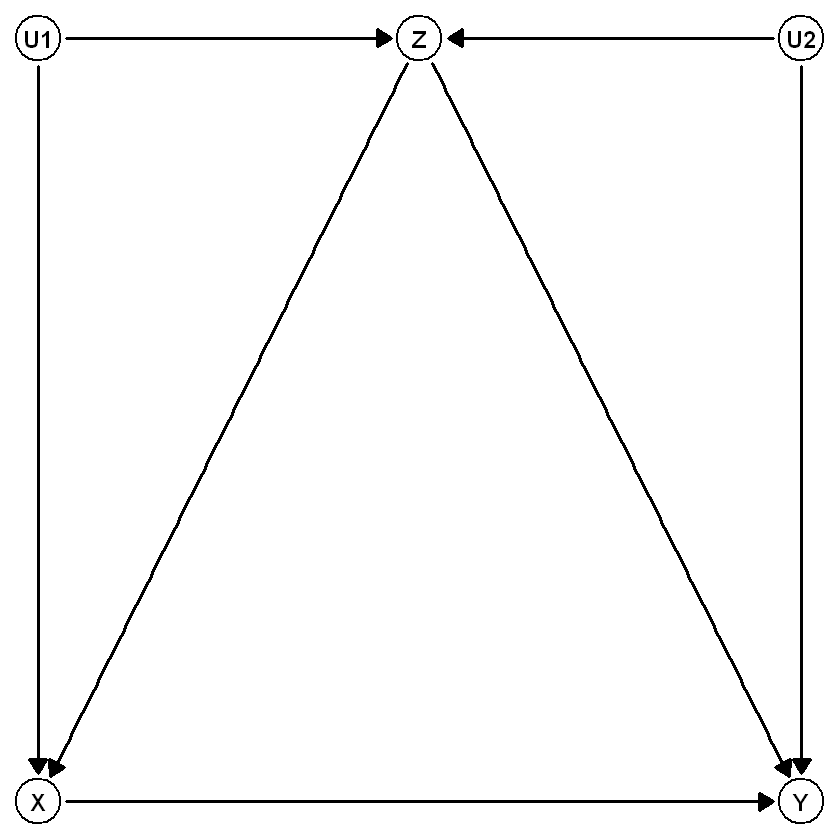

In [29]:
library(igraph)
library(ggraph)
library(ggplot2)

# Definir aristas del DAG
edges <- data.frame(
  from = c("U1","U2","Z","U1","X","Z","U2"),
  to   = c("Z","Z","X","X","Y","Y","Y")
)

g <- graph_from_data_frame(edges, directed = TRUE)

# Posiciones fijas
coords <- data.frame(
  name = c("U1","Z","U2","X","Y"),
  x = c(0.0, 1.2, 2.4, 0.0, 2.4),
  y = c(1.2, 1.2, 1.2, 0.0, 0.0)
)

# Asociar coordenadas
V(g)$x <- coords$x[match(V(g)$name, coords$name)]
V(g)$y <- coords$y[match(V(g)$name, coords$name)]

# Graficar
p <- ggraph(g, layout = "manual", x = V(g)$x, y = V(g)$y) +
  geom_edge_link(
    arrow = arrow(type = "closed", length = unit(3.5,"mm")),
    start_cap = circle(6,"mm"), end_cap = circle(6,"mm"),
    edge_width = 1, lineend = "round", color = "black"
  ) +
  geom_node_point(shape = 21, size = 12,
                  fill = "white", color = "black", stroke = 1.2) +
  geom_node_text(aes(label = name), size = 5, fontface = "bold") +
  theme_void()

print(p)

# Guardar figura (usa tu URL ya definida en R)
ggsave(filename = paste0(URL, "DAG_DAM_Alt.png"),
       plot = p, width = 7, height = 4, dpi = 300)




In [30]:
set.seed(123)
n <- 50000

U1 <- rnorm(n)
U2 <- rnorm(n)

# Relaciones del DAG
Z <- 0.8*U1 + 0.8*U2 + rnorm(n)             # U1→Z, U2→Z
X <- 0.9*U1 + 0.7*Z  + rnorm(n)             # Z→X, U1→X
Y <- 1.0*X + 1.0*Z + 1.0*U2 + rnorm(n)      # X→Y, Z→Y, U2→Y

df <- data.frame(Y = Y, X = X, Z = Z, U1 = U1, U2 = U2)



## 3.5) Regressions (1.5 points)

In [31]:
# Requiere: df con columnas Y, X, Z, U1, U2
# Paquetes
library(lmtest)
library(sandwich)

# OLS con SE robustos HC1
fit_hc1 <- function(formula, data) {
  m <- lm(formula, data = data)
  ct <- coeftest(m, vcov = vcovHC(m, type = "HC1"))
  list(model = m, ct = ct)
}

controls_pool <- c("Z","U1","U2")

# Todas las combinaciones de controles, incluyendo 0
specs <- list(character(0))
for (k in 1:length(controls_pool)) {
  cmb <- combn(controls_pool, k, simplify = FALSE)
  specs <- c(specs, cmb)
}

rows <- list()
models <- list()

cat("== Regression results for β_X (academic format) ==\n")
cat(strrep("-", 90), "\n", sep = "")
cat(sprintf("%-20s %10s %10s %22s %10s %8s %6s\n",
            "Model", "β_X", "SE", "95% CI", "p-value", "R²", "n"))
cat(strrep("-", 90), "\n", sep = "")

for (comb in specs) {
  label <- if (length(comb) == 0) "No controls" else paste(comb, collapse = " + ")
  fml   <- as.formula(paste("Y ~", paste(c("X", comb), collapse = " + ")))
  m     <- fit_hc1(fml, df)
  models[[label]] <- m

  # Extraer coef y SE de X
  est <- m$ct["X", 1]
  se  <- m$ct["X", 2]
  t   <- m$ct["X", 3]
  p   <- m$ct["X", 4]
  z   <- qnorm(0.975)
  lo  <- est - z * se
  hi  <- est + z * se
  r2  <- summary(m$model)$r.squared
  n   <- nobs(m$model)

  cat(sprintf("%-20s %10.4f %10.4f [%6.4f, %6.4f] %10.3g %8.3f %6d\n",
              label, est, se, lo, hi, p, r2, n))
}

cat(strrep("-", 90), "\n", sep = "")



== Regression results for β_X (academic format) ==
------------------------------------------------------------------------------------------
Model                      β_X         SE                 95% CI    p-value      R²      n
------------------------------------------------------------------------------------------
No controls              1.7294     0.0044 [1.7208, 1.7380]          0    0.757  50000
Z                        0.8406     0.0046 [0.8316, 0.8496]          0    0.893  50000
U1                       1.9417     0.0063 [1.9293, 1.9542]          0    0.767  50000
U2                       1.5177     0.0030 [1.5118, 1.5237]          0    0.892  50000
Z + U1                   0.9958     0.0056 [0.9848, 1.0069]          0    0.897  50000
Z + U2                   1.0008     0.0037 [0.9936, 1.0080]          0    0.936  50000
U1 + U2                  1.4704     0.0047 [1.4611, 1.4797]          0    0.892  50000
Z + U1 + U2              0.9996     0.0045 [0.9909, 1.0083]        

## 3.6) Summary Table ( Coef and SE) (1 points)

In [33]:
# --- 2) Guardar SOLO coeficiente y error estándar en un data.frame ---
rows <- lapply(names(models), function(label) {
  m <- models[[label]]
  rn <- rownames(m$ct)
  if (!("X" %in% rn)) {
    est <- se <- NA_real_
  } else {
    est <- m$ct["X", 1]
    se  <- m$ct["X", 2]
  }
  data.frame(
    Controls = label,
    `β_X`    = est,
    `SE(β_X)`= se,
    stringsAsFactors = FALSE,
    check.names = FALSE
  )
})

results_df <- do.call(rbind, rows)

# Orden: "No controls" primero, luego por número de covariables y alfabético
# Cuenta covariables: para "No controls" = 0; si no, cuenta '+' + 1
plus_count <- function(s) nchar(gsub("[^+]", "", s))
cov_count  <- ifelse(results_df$Controls == "No controls", 0, plus_count(results_df$Controls) + 1)

ord <- order(results_df$Controls != "No controls", cov_count, results_df$Controls)
results_df <- results_df[ord, , drop = FALSE]
row.names(results_df) <- NULL

# Redondear solo columnas numéricas
num_cols <- sapply(results_df, is.numeric)
results_df[num_cols] <- lapply(results_df[num_cols], function(x) round(x, 4))

cat("\n== Stored estimates (for downstream use) ==\n")
cat(strrep("-", 50), "\n", sep = "")
print(results_df, row.names = FALSE)
cat(strrep("-", 50), "\n", sep = "")




== Stored estimates (for downstream use) ==
--------------------------------------------------
    Controls    β_X SE(β_X)
 No controls 1.7294  0.0044
          U1 1.9417  0.0063
          U2 1.5177  0.0030
           Z 0.8406  0.0046
     U1 + U2 1.4704  0.0047
      Z + U1 0.9958  0.0056
      Z + U2 1.0008  0.0037
 Z + U1 + U2 0.9996  0.0045
--------------------------------------------------


## 3.7) .text and .txt format ( Coef and SE) (1.5 points)

In [35]:
# Paquetes
library(lmtest)
library(sandwich)

# OLS con SE robustos HC1
fit_hc1 <- function(formula, data) {
  m  <- lm(formula, data = data)
  ct <- coeftest(m, vcov = vcovHC(m, type = "HC1"))
  list(model = m, ct = ct)
}

# 1) Todas las combinaciones de controles {Z, U1, U2}
controls_pool <- c("Z", "U1", "U2")
specs <- list(character(0))  # "No controls"
for (k in 1:length(controls_pool)) {
  specs <- c(specs, combn(controls_pool, k, simplify = FALSE))
}

# 2) Estimar y recolectar β y SE de X
rows <- lapply(specs, function(comb) {
  label <- if (length(comb) == 0) "No controls" else paste(comb, collapse = ", ")
  fml   <- as.formula(paste("Y ~", paste(c("X", comb), collapse = " + ")))
  m     <- fit_hc1(fml, df)
  est   <- m$ct["X", 1]
  se    <- m$ct["X", 2]
  data.frame(Controls = label, `β` = est, SE = se, check.names = FALSE)
})
table <- do.call(rbind, rows)

# 3) Orden: "No controls" primero, luego por #controles, luego alfabético
count_controls <- function(s) if (s == "No controls") 0L else length(strsplit(s, ",\\s*")[[1]])
ord <- order(table$Controls != "No controls",
             vapply(table$Controls, count_controls, integer(1)),
             table$Controls)
table <- table[ord, , drop = FALSE]

# 4) Redondear a 4 decimales
table$β  <- round(table$β,  4)
table$SE <- round(table$SE, 4)

# 5) Exportar TXT (tab) y LaTeX
txt_path <- file.path(URL, "table_beta_se.txt")
tex_path <- file.path(URL, "table_beta_se.tex")

# TXT con índice como filas (tipo pandas set_index)
table_out <- table
row.names(table_out) <- table_out$Controls
table_out$Controls <- NULL
utils::write.table(table_out, file = txt_path, sep = "\t",
                   quote = FALSE, col.names = NA)

# LaTeX (xtable). Instalar si falta
if (!requireNamespace("xtable", quietly = TRUE)) install.packages("xtable")

# Renombrar columnas para LaTeX; mantener filas sin sanitizar
table_out_tex <- table_out
colnames(table_out_tex) <- c("$\\beta$", "SE")
latex_obj <- xtable::xtable(table_out_tex, align = "lrr")
print(latex_obj,
      file = tex_path,
      include.rownames = TRUE,
      sanitize.rownames.function = identity,
      sanitize.colnames.function = identity,
      floating = FALSE)

# 6) Mostrar en consola
cat(sprintf("Saved TXT: %s\nSaved LaTeX: %s\n", txt_path, tex_path))
cat("\n== Stored estimates (β and SE) ==\n")
print(table_out)


Saved TXT: C:/Users/User/Desktop/Avances Asignación 03/R/Output//table_beta_se.txt
Saved LaTeX: C:/Users/User/Desktop/Avances Asignación 03/R/Output//table_beta_se.tex

== Stored estimates (β and SE) ==
                 β     SE
No controls 1.7294 0.0044
U1          1.9417 0.0063
U2          1.5177 0.0030
Z           0.8406 0.0046
U1, U2      1.4704 0.0047
Z, U1       0.9958 0.0056
Z, U2       1.0008 0.0037
Z, U1, U2   0.9996 0.0045


# 3.8) Based on your findings, in what way(s) can you get a good estimate of the causal effect? (0.5 point)

From the regression results, we know the true causal effect of $X$ on $Y$ is $1$.  
- Models without controls or with only one control ($Z$, $U1$, $U2$) are **biased**, as their estimates are far from $1$ (e.g., $1.7294$, $0.8406$, $1.9417$, $1.5177$).  
- Good estimates (close to $1$ with narrow CIs) are obtained only when controlling simultaneously for $Z$ and at least one of the true confounders ($U1$, $U2$).  
- For instance:  
  - $Y \sim X + Z + U1 \;\;\; \hat\beta_X \approx 0.9958$  
  - $Y \sim X + Z + U2 \;\;\; \hat\beta_X \approx 1.0008$  
  - $Y \sim X + Z + U1 + U2 \;\;\; \hat\beta_X \approx 0.9996$  

All these estimates are very close to the true value of $1$ and unbiased within sampling error.



# 3.9) What is the minimal sufficient set of controls to get a good estimate? (0.5 point)

The minimal sufficient adjustment set is **$\{Z, U1\}$** or alternatively **$\{Z, U2\}$**.  
Controlling only $Z$ introduces collider bias, and controlling only $U1$ or $U2$ leaves confounding unaddressed. But once $Z$ and one of the confounders are included, the backdoor paths are blocked, yielding unbiased estimates of $\beta_X$.



# 3.10) Provide intuition on why you can get good estimates controlling for the variables you established above (0.5 point)

- $U1$ and $U2$ are true confounders because they influence both $X$ and $Y$.  
- $Z$ is a collider that also has a direct effect on $Y$ and an effect on $X$. If omitted, $Z$ creates bias in the regression of $Y$ on $X$.  
- By controlling for $Z$ and one of the confounders ($U1$ or $U2$), we block the spurious paths:  
  - $X \leftarrow U1 \rightarrow Y$  
  - $X \leftarrow Z \leftarrow U2 \rightarrow Y$  
- This ensures that the only remaining path from $X$ to $Y$ is the **causal path**, so the regression recovers the true causal effect $\beta_X = 1$.  
